# 2 MPC
This notebook contains the CVXPY implementation of a MPC
This is the simplest one

### MPC Problem formulation

**Model Predictive Control** refers to the control approach of **numerically** solving a optimization problem at each time step. 

The controller generates a control signal over a fixed lenght T (Horizon) at each time step.

![mpc](img/mpc_block_diagram.png)

![mpc](img/mpc_t.png)

#### Linear MPC Formulation

Linear MPC makes use of the **LTI** (Linear time invariant) discrete state space model, wich represents a motion model used for Prediction.

$x_{t+1} = Ax_t + Bu_t$

The LTI formulation means that **future states** are linearly related to the current state and actuator signal. Hence, the MPC seeks to find a **control policy** U over a finite lenght horizon.

$U={u_{t|t}, u_{t+1|t}, ...,u_{t+T|t}}$

The objective function used minimize (drive the state to 0) is:

$
\begin{equation}
\begin{aligned}
\min_{} \quad &  \sum^{t+T-1}_{j=t} x^T_{j|t}Qx_{j|t} + u^T_{j|t}Ru_{j|t}\\
\textrm{s.t.} \quad &  x(0) = x0\\
  & x_{j+1|t} = Ax_{j|t}+Bu_{j|t}) \quad  \textrm{for} \quad t<j<t+T-1    \\
\end{aligned}
\end{equation}
$

Other linear constrains may be applied,for instance on the control variable:

$ U_{MIN} < u_{j|t} < U_{MAX}    \quad  \textrm{for} \quad t<j<t+T-1 $

The objective fuction accounts for quadratic error on deviation from 0 of the state and the control inputs sequences. Q and R are the **weight matrices** and are used to tune the response.

Because the goal is tracking a **reference signal** such as a trajectory, the objective function is rewritten as:

$
\begin{equation}
\begin{aligned}
\min_{} \quad &  \sum^{t+T-1}_{j=t} \delta x^T_{j|t}Q\delta x_{j|t} + u^T_{j|t}Ru_{j|t}
\end{aligned}
\end{equation}
$

where the error w.r.t desired state is accounted for:

$ \delta x = x_{j,t,ref} - x_{j,t} $

# Problem Formulation: Study case

In this case, the objective function to minimize is given by:

https://borrelli.me.berkeley.edu/pdfpub/IV_KinematicMPC_jason.pdf

$
\begin{equation}
\begin{aligned}
\min_{} \quad &  \sum^{t+T-1}_{j=t} (x_{j} - x_{j,ref})^TQ(x_{j} - x_{j,ref}) + \sum^{t+T-1}_{j=t+1} u^T_{j}Ru_{j} + (u_{j} - u_{j-1})^TP(u_{j} - u_{j-1}) \\
\textrm{s.t.} \quad &  x(0) = x0\\
  & x_{j+1} = Ax_{j}+Bu_{j} \quad  \textrm{for} \quad t<j<t+T-1  \\
  & u_{MIN} < u_{j} < u_{MAX} \quad  \textrm{for} \quad t<j<t+T-1 \\
  & \dot{u}_{MIN} < \frac{(u_{j} - u_{j-1})}{ts} < \dot{u}_{MAX} \quad  \textrm{for} \quad t+1<j<t+T-1 \\
\end{aligned}
\end{equation}
$


Where R,P,Q are the cost matrices used to tune the response.


## PRELIMINARIES

* linearized system dynamics
* function to represent the track
* function to represent the **reference trajectory** to track

In [1]:
import numpy as np
from scipy.integrate import odeint
from scipy.interpolate import interp1d
import cvxpy as cp
from scipy.integrate import solve_ivp

import matplotlib.pyplot as plt

plt.style.use("ggplot")

import time

In [2]:
"""
Control problem statement.
"""

N = 6  # number of state variables
M = 3  # number of control variables
T = 20  # Prediction Horizon
DT = 0.2  # discretization step


def get_linear_model(x_bar):
    """
    Computes the LTI approximated state space model x' = Ax + Bu + C
    """





    A = np.eye(N)
    A[0, 3] = DT
    A[1, 4] = DT
    A[2, 5] = DT



    B = np.zeros((N, M))
    tmp = 0.5*DT*DT
    B[0, 0] = tmp
    B[1, 1] = tmp
    B[2, 2] = tmp
    B[3, 0] = DT
    B[4, 1] = DT
    B[5, 2] = DT




    return np.round(A, 4), np.round(B, 4)


"""
the ODE is used to update the simulation given the mpc results
I use this insted of using the LTI twice
"""



def kinematic_model(x, t, u):#t, state, control):
    """
    Holonomic drone kinematic model.

    State:
        state = [x, y, yaw, vx, vy, yaw_rate]

    Control:
        control = [ax, ay, yaw_accel]

    Returns:
        state_dot = [x_dot, y_dot, yaw_dot,
                     vx_dot, vy_dot, yaw_rate_dot]
    """

    x, y, yaw, vx, vy, yaw_rate = x
    ax, ay, yaw_accel = u

    state_dot = np.array([
        vx,          # x_dot
        vy,          # y_dot
        yaw_rate,    # yaw_dot
        ax,          # vx_dot
        ay,          # vy_dot
        yaw_accel    # yaw_rate_dot
    ])

    return state_dot


def predict(x0, u):
    """ """

    x_ = np.zeros((N, T + 1))

    x_[:, 0] = x0

    # solve ODE

    # sol = solve_ivp(
    #     fun=lambda t, x: kinematic_model(t, x, control),
    #     t_span=(0.0, DT),
    #     y0=state,
    #     t_eval=[dt]
    # )
    print(x0)
    # next_state = sol.y[:, -1]
    for t in range(1, T + 1):

        tspan = [0, DT]
        x_next = odeint(kinematic_model, x0, tspan, args=(u[:, t - 1],))

        x0 = x_next[1]
        x_[:, t] = x_next[1]

    return x_


def compute_path_from_wp(start_xp, start_yp, step=0.1):
    """
    Computes a reference path given a set of waypoints
    """

    final_xp = []
    final_yp = []
    delta = step  # [m]

    for idx in range(len(start_xp) - 1):
        section_len = np.sum(
            np.sqrt(
                np.power(np.diff(start_xp[idx : idx + 2]), 2)
                + np.power(np.diff(start_yp[idx : idx + 2]), 2)
            )
        )

        interp_range = np.linspace(0, 1, np.floor(section_len / delta).astype(int))

        fx = interp1d(np.linspace(0, 1, 2), start_xp[idx : idx + 2], kind=1)
        fy = interp1d(np.linspace(0, 1, 2), start_yp[idx : idx + 2], kind=1)

        final_xp = np.append(final_xp, fx(interp_range))
        final_yp = np.append(final_yp, fy(interp_range))

    dx = np.append(0, np.diff(final_xp))
    dy = np.append(0, np.diff(final_yp))
    theta = np.arctan2(dy, dx) # calculating the theta of the path based on the difference between pts

    return np.vstack((final_xp, final_yp, theta))


def get_nn_idx(state, path):
    """
    Computes the index of the waypoint closest to vehicle
    """

    dx = state[0] - path[0, :]
    dy = state[1] - path[1, :]
    dist = np.hypot(dx, dy)
    nn_idx = np.argmin(dist)

    try:
        v = [
            path[0, nn_idx + 1] - path[0, nn_idx],
            path[1, nn_idx + 1] - path[1, nn_idx],
        ]
        v /= np.linalg.norm(v)

        d = [path[0, nn_idx] - state[0], path[1, nn_idx] - state[1]]

        if np.dot(d, v) > 0:
            target_idx = nn_idx
        else:
            target_idx = nn_idx + 1

    except IndexError as e:
        target_idx = nn_idx

    return target_idx


def get_ref_trajectory(state, path, target_v):
    """
    Adapted from pythonrobotics
    """
    xref = np.zeros((N, T + 1))

    # sp = np.ones((1,T +1))*target_v #speed profile

    ncourse = path.shape[1]

    ind = get_nn_idx(state, path)

    # ---------------------------------------------------------
    # Precompute cumulative path distance
    # ---------------------------------------------------------
    dx = np.diff(path[0, :])
    dy = np.diff(path[1, :])

    ds = np.sqrt(dx**2 + dy**2)

    s = np.zeros(ncourse)
    s[1:] = np.cumsum(ds)

    xref[0, 0] = path[0, ind]  # X
    xref[1, 0] = path[1, ind]  # Y
    xref[2, 0] = path[2, ind]  # Theta
    xref[3, 0] = target_v  # vx
    xref[4, 0] = target_v  # vy


    dl = 0.05  # Waypoints spacing [m]
    travel = 0.0

    for i in range(T + 1):
        # Desired distance along path at this horizon step
        travel = abs(target_v) * DT * i

        target_s = s[ind] + travel

        # Find waypoint corresponding to desired path distance
        ref_ind = np.searchsorted(s, target_s)

        if ref_ind >= ncourse:
            ref_ind = ncourse - 1

        # -----------------------------------------------------
        # Position reference
        # -----------------------------------------------------
        xref[0, i] = path[0, ref_ind]
        xref[1, i] = path[1, ref_ind]

        # -----------------------------------------------------
        # Yaw reference
        # -----------------------------------------------------
        xref[2, i] = path[2, ref_ind]

        # -----------------------------------------------------
        # Velocity direction from PATH TANGENT,
        # not from drone yaw
        # -----------------------------------------------------
        if ref_ind < ncourse - 1:
            path_dx = path[0, ref_ind + 1] - path[0, ref_ind]
            path_dy = path[1, ref_ind + 1] - path[1, ref_ind]

        elif ref_ind > 0:
            path_dx = path[0, ref_ind] - path[0, ref_ind - 1]
            path_dy = path[1, ref_ind] - path[1, ref_ind - 1]

        else:
            path_dx = 0.0
            path_dy = 0.0

        path_norm = np.hypot(path_dx, path_dy)

        if path_norm > 1e-6:
            vx_ref = target_v * path_dx / path_norm
            vy_ref = target_v * path_dy / path_norm
        else:
            vx_ref = 0.0
            vy_ref = 0.0

        # -----------------------------------------------------
        # Stop at end of path
        # -----------------------------------------------------
        if ref_ind == ncourse - 1:
            vx_ref = 0.0
            vy_ref = 0.0

        xref[3, i] = vx_ref
        xref[4, i] = vy_ref

        # Desired yaw rate
        # Start simple: zero yaw rate reference.
        xref[5, i] = 0.0

    return xref

## MPC 

test single iteration

In [3]:
%%time

MAX_SPEED = 1.5  # m/s
MAX_STEER = np.radians(30)  # rad
MAX_ACC = 1.0
REF_VEL = 1.0
# T = 50
track = compute_path_from_wp([0, 3, 6], [0, 0, 0], 0.05)

# Starting Condition
x0 = np.zeros(N)
x0[0] = 0  # x
x0[1] = -0.25  # y
x0[2] = np.radians(-0)  # yaw
x0[3] = 0.0  # vx
x0[4] = 0.0  # vy
x0[5] = 0.0  # w

# starting guess
u_bar = np.zeros((M, T))
u_bar[0, :] = MAX_ACC / 2  # ax
u_bar[1, :] = MAX_ACC / 2  # ay

u_bar[2, :] = 0.1  # delta

# dynamics starting state w.r.t world frame
x_bar = np.zeros((N, T + 1))
x_bar[:, 0] = x0

# prediction for linearization of costrains
for t in range(1, T + 1):
    xt = x_bar[:, t - 1].reshape(N, 1)
    ut = u_bar[:, t - 1].reshape(M, 1)
    A, B = get_linear_model(xt)
    xt_plus_one = np.squeeze(np.dot(A, xt) + np.dot(B, ut))
    x_bar[:, t] = xt_plus_one

# CVXPY Linear MPC problem statement
x = cp.Variable((N, T + 1))
u = cp.Variable((M, T))
cost = 0
constr = []

# Cost Matrices
Q = np.diag([10, 10, 10, 10, 10, 10])  # state error cost
Qf = np.diag([10, 10, 10, 10, 10, 10])  # state  final error cost
R = np.diag([10, 10, 10])  # input cost
R_ = np.diag([10, 10, 10])  # input rate of change cost

# Get Reference_traj
x_ref = get_ref_trajectory(x_bar[:, 0], track, REF_VEL)

# Prediction Horizon
for t in range(T):

    # Tracking Error
    cost += cp.quad_form(x[:, t] - x_ref[:, t], Q)

    # Actuation effort
    cost += cp.quad_form(u[:, t], R)

    # Actuation rate of change
    if t < (T - 1):
        cost += cp.quad_form(u[:, t + 1] - u[:, t], R_)

    # Kinrmatics Constrains (Linearized model)
    A, B= get_linear_model(x_bar[:, t])
    constr += [x[:, t + 1] == A @ x[:, t] + B @ u[:, t]]

# Final Point tracking
cost += cp.quad_form(x[:, T] - x_ref[:, T], Qf)

# sums problem objectives and concatenates constraints.
constr += [x[:, 0] == x_bar[:, 0]]  # starting condition
constr += [x[3, :] <= MAX_SPEED]  # max speed
# constr += [x[3, :] >= 0.0]  # min_speed (not really needed)
constr += [x[4, :] <= MAX_SPEED]  # max speed
# constr += [x[4, :] >= 0.0]  # min_speed (not really needed)
constr += [cp.abs(u[0, :]) <= MAX_ACC]
constr += [cp.abs(u[1, :]) <= MAX_ACC]  # max acc
# max acc
constr += [cp.abs(u[2, :]) <= MAX_STEER]  # max steer
# for t in range(T):
#     if t < (T - 1):
#         constr += [cp.abs(u[0,t] - u[0,t-1])/DT <= MAX_ACC]     #max acc
#         constr += [cp.abs(u[1,t] - u[1,t-1])/DT <= MAX_STEER]   #max steer

prob = cp.Problem(cp.Minimize(cost), constr)
solution = prob.solve(solver=cp.OSQP, verbose=True)

(CVXPY) Sep 26 02:53:44 PM: Your problem has 186 variables, 228 constraints, and 0 parameters.
(CVXPY) Sep 26 02:53:44 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Sep 26 02:53:44 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Sep 26 02:53:44 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Sep 26 02:53:44 PM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Sep 26 02:53:44 PM: Compiling problem (target solver=OSQP).
(CVXPY) Sep 26 02:53:44 PM: Reduction chain: CvxAttr2Constr -> Qp2SymbolicQp -> QpMatrixStuffing -> OSQP
(CVXPY) Sep 26 02:53:44 PM: Applying reduction CvxAttr2Constr
(CVXPY) Sep 26 02:53:44 PM: Applying reduction Qp2SymbolicQp
(CVXPY) Sep 26 02:53:44 PM: Applying reduction QpMatrixStuffing
(CVXPY) Sep 26 02:53:44 PM: Applying reduction OSQP
(CVXPY) Sep 26 02:53:44 PM: Finished problem compilation 

                                     CVXPY                                     
                                     v1.7.5                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
-----------------------------------------------------------------
           OSQP v1.0.0  -  Operator Splitting QP Solver
              (c) The OSQP Developer Team
-----------------------------------------------------------------
problem:  variables n = 489, constraints m = 591
          nnz(P) + nnz(A) = 1554
settings: algebra = Built-in,
          OSQPInt 

[ 0.   -0.25  0.    0.    0.    0.  ]


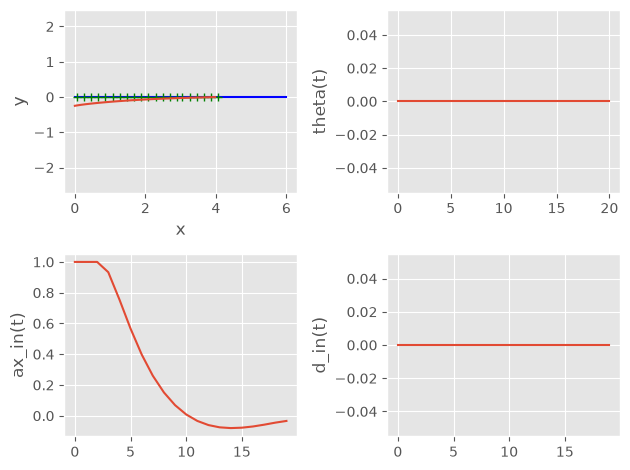

In [4]:
x_mpc = np.array(x.value[0, :]).flatten()
y_mpc = np.array(x.value[1, :]).flatten()
theta_mpc = np.array(x.value[2, :]).flatten()
vx_mpc = np.array(x.value[3, :]).flatten()
vx_mpc = np.array(x.value[4, :]).flatten()

ax_mpc = np.array(u.value[0, :]).flatten()
ay_mpc = np.array(u.value[1, :]).flatten()
delta_mpc = np.array(u.value[2, :]).flatten()

# simulate robot state trajectory for optimized U
x_traj = predict(x0, np.vstack((ax_mpc,ay_mpc, delta_mpc)))

# plt.figure(figsize=(15,10))
# plot trajectory
plt.subplot(2, 2, 1)
plt.plot(track[0, :], track[1, :], "b")
plt.plot(x_ref[0, :], x_ref[1, :], "g+")
plt.plot(x_traj[0, :], x_traj[1, :])
plt.axis("equal")
plt.ylabel("y")
plt.xlabel("x")

# plot v(t)
plt.subplot(2, 2, 3)
plt.plot(ax_mpc)
plt.ylabel("ax_in(t)")
# plt.xlabel('time')


plt.subplot(2, 2, 2)
plt.plot(theta_mpc)
plt.ylabel("theta(t)")

plt.subplot(2, 2, 4)
plt.plot(delta_mpc)
plt.ylabel("d_in(t)")

plt.tight_layout()
plt.show()

## full track demo

In [5]:
track = compute_path_from_wp(
    [0, 3, 4, 6, 10, 12, 14, 6, 1, 0], [0, 0, 2, 4, 3, 3, -2, -6, -2, -2], 0.05
)

# track = compute_path_from_wp([0,10,10,0],
#                              [0,0,1,1],0.05)

sim_duration = 200  # time steps
opt_time = []

x_sim = np.zeros((N, sim_duration))
u_sim = np.zeros((M, sim_duration - 1))

MAX_SPEED = 3.5  # m/s
MAX_ACC = 3.0  # m/ss
MAX_D_ACC = 1.0  # m/sss
MAX_STEER = np.radians(30)  # rad
MAX_D_STEER = np.radians(30)  # rad/s
REF_VEL = 3.0  # m/s

# Starting Condition
x0 = np.zeros(N)
x0[0] = 0  # x
x0[1] = -0.25  # y
x0[2] = np.radians(-0)  # yaw
x0[3] = 0.0  # vx
x0[4] = 0.0  # vy
x0[5] = 0.0  # w

# starting guess
u_bar = np.zeros((M, T))
u_bar[0, :] = MAX_ACC / 2  # ax
u_bar[1, :] = MAX_ACC / 2  # ay
u_bar[2, :] = 0.1  # delta

for sim_time in range(sim_duration - 1):

    iter_start = time.time()

    # dynamics starting state
    x_bar = np.zeros((N, T + 1))
    x_bar[:, 0] = x_sim[:, sim_time]

    # prediction for linearization of costrains
    for t in range(1, T + 1):
            xt = x_bar[:, t - 1].reshape(N, 1)
            ut = u_bar[:, t - 1].reshape(M, 1)
            A, B = get_linear_model(xt)
            xt_plus_one = np.squeeze(np.dot(A, xt) + np.dot(B, ut))
            x_bar[:, t] = xt_plus_one

    # CVXPY Linear MPC problem statement
    x = cp.Variable((N, T + 1))
    u = cp.Variable((M, T))
    cost = 0
    constr = []

    # Cost Matrices
    # Q = np.diag([20, 20, 10, 0])  # state error cost
    # Qf = np.diag([30, 30, 30, 0])  # state final error cost
    # R = np.diag([10, 10])  # input cost
    # R_ = np.diag([10, 10])  # input rate of change cost
    # Cost Matrices
    Q = np.diag([20, 20, 0, 10, 10, 0])  # state error cost
    Qf = np.diag([30, 30, 0, 30, 30, 0])  # state  final error cost
    R = np.diag([10, 10, 10])  # input cost
    R_ = np.diag([10, 10, 10])  # input rate of change cost
    # Get Reference_traj
    x_ref = get_ref_trajectory(x_bar[:, 0], track, REF_VEL)

    # Prediction Horizon
    for t in range(T):

        # Tracking Error
        cost += cp.quad_form(x[:, t] - x_ref[:, t], Q)

        # Actuation effort
        cost += cp.quad_form(u[:, t], R)

        # Actuation rate of change
        if t < (T - 1):
            cost += cp.quad_form(u[:, t + 1] - u[:, t], R_)
            constr += [
                cp.abs(u[0, t + 1] - u[0, t]) / DT <= MAX_D_ACC
            ]  # max acc rate of change
            constr += [
                cp.abs(u[1, t + 1] - u[1, t]) / DT <= MAX_D_STEER
            ]  # max steer rate of change

        # Kinrmatics Constrains (Linearized model)
        A, B = get_linear_model(x_bar[:, t])
        constr += [x[:, t + 1] == A @ x[:, t] + B @ u[:, t]]

    # Final Point tracking
    cost += cp.quad_form(x[:, T] - x_ref[:, T], Qf)

    # sums problem objectives and concatenates constraints.
    constr += [x[:, 0] == x_bar[:, 0]]  # starting condition
    constr += [cp.abs(x[3, :]) <= MAX_SPEED]  # max speed
    # constr += [x[3, :] >= 0.0]  # min_speed (not really needed)
    constr += [cp.abs(x[4, :]) <= MAX_SPEED]  # max speed
    # constr += [x[4, :] >= 0.0]  # min_speed (not really needed)
    constr += [cp.abs(u[0, :]) <= MAX_ACC]
    constr += [cp.abs(u[1, :]) <= MAX_ACC]  # max acc

    # Solve
    prob = cp.Problem(cp.Minimize(cost), constr)
    solution = prob.solve(solver=cp.OSQP, verbose=False)

    # retrieved optimized U and assign to u_bar to linearize in next step
    u_bar = np.vstack(
        (np.array(u.value[0, :]).flatten(), (np.array(u.value[1, :]).flatten()), (np.array(u.value[2, :]).flatten()))
    )

    u_sim[:, sim_time] = u_bar[:, 0]

    # Measure elpased time to get results from cvxpy
    opt_time.append(time.time() - iter_start)

    # move simulation to t+1
    tspan = [0, DT]
    x_sim[:, sim_time + 1] = odeint(
        kinematic_model, x_sim[:, sim_time], tspan, args=(u_bar[:, 0],)
    )[1]

print(
    "CVXPY Optimization Time: Avrg: {:.4f}s Max: {:.4f}s Min: {:.4f}s".format(
        np.mean(opt_time), np.max(opt_time), np.min(opt_time)
    )
)

CVXPY Optimization Time: Avrg: 0.1021s Max: 0.1711s Min: 0.0805s


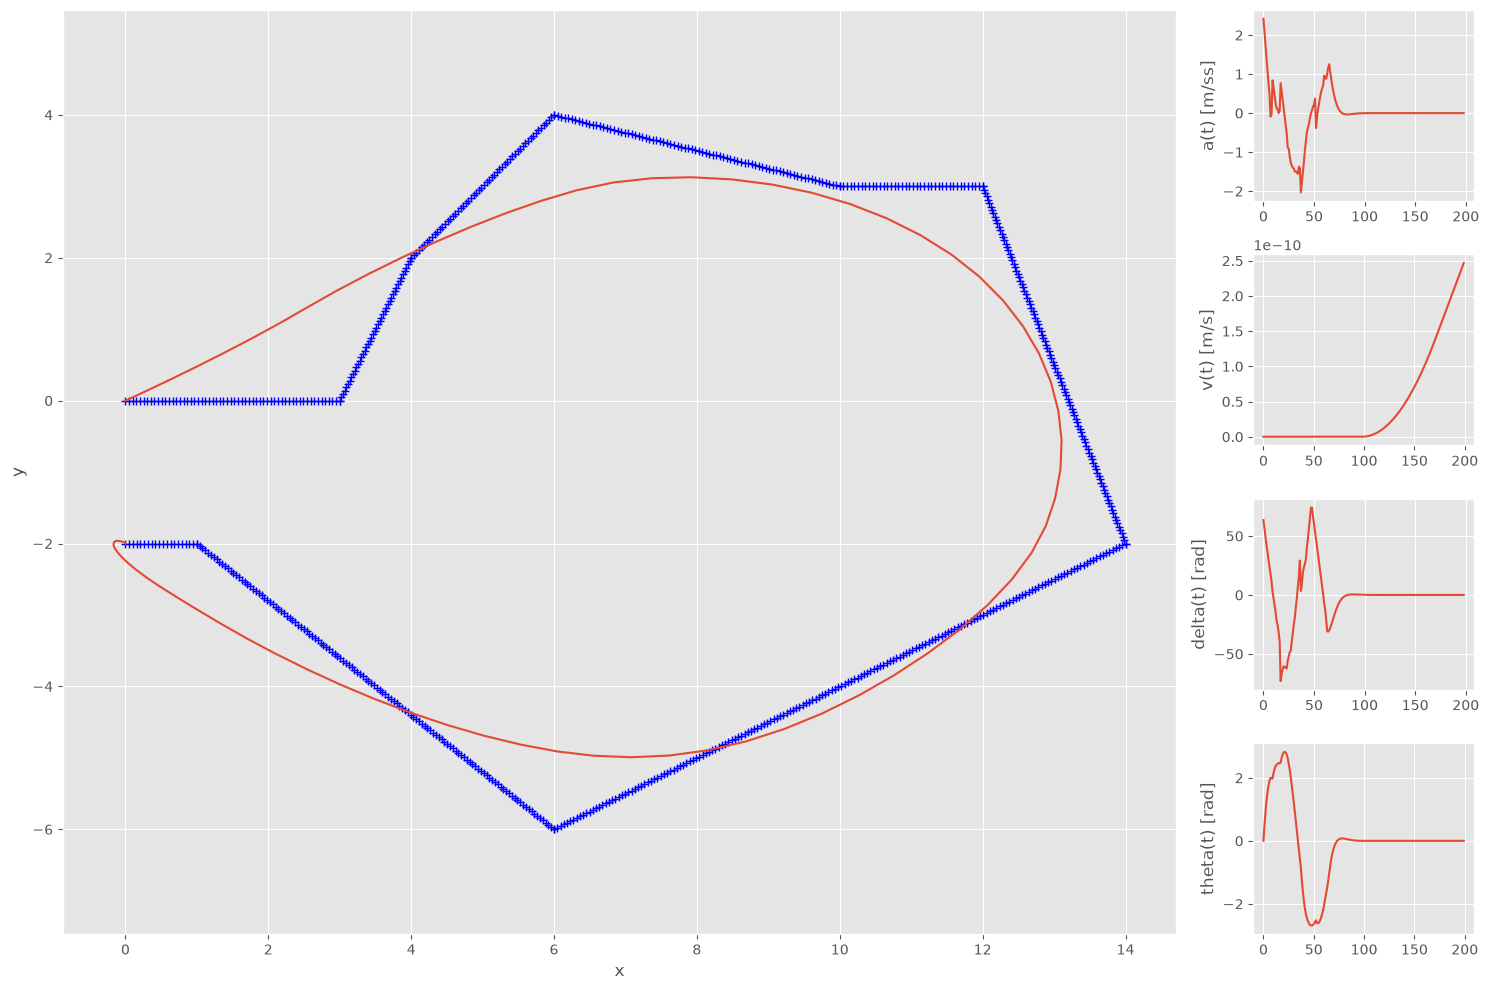

In [6]:
# plot trajectory
grid = plt.GridSpec(4, 5)

plt.figure(figsize=(15, 10))

plt.subplot(grid[0:4, 0:4])
plt.plot(track[0, :], track[1, :], "b+")
plt.plot(x_sim[0, :], x_sim[1, :])
plt.axis("equal")
plt.ylabel("y")
plt.xlabel("x")

plt.subplot(grid[0, 4])
plt.plot(u_sim[0, :])
plt.ylabel("a(t) [m/ss]")

plt.subplot(grid[1, 4])
plt.plot(x_sim[2, :])
plt.ylabel("v(t) [m/s]")

plt.subplot(grid[2, 4])
plt.plot(np.degrees(u_sim[1, :]))
plt.ylabel("delta(t) [rad]")

plt.subplot(grid[3, 4])
plt.plot(x_sim[3, :])
plt.ylabel("theta(t) [rad]")

plt.tight_layout()
plt.show()